
# Customer Analytics & Segmentation for an Online Retail Business

## Project Overview

This project explores customer purchasing behavior using the Online Retail dataset from a UK-based e-commerce retailer.

The goal is to transform raw transactional data into actionable business insights by applying a variety of customer analytics techniques. Rather than focusing on a single metric, this project provides a comprehensive understanding of customer value, purchasing behavior, and long-term engagement.

This project aims to answer the following business questions:

- Who are the most valuable customers?
- Which customer segments contribute the most revenue?
- How often do customers return after their first purchase?
- What is the average order value across different customer groups?
- Which cohorts demonstrate the strongest customer retention?
- Can customers be segmented based on purchasing behavior?
- How can the business improve customer loyalty and maximize revenue?

The project is organized into the following stages:
1. Business Understanding

2. Data Understanding

3. Data Preparation

4. Exploratory Data Analysis

5. Customer Analytics
      - Cohort Analysis
      - RFM Analysis
      - Customer Segmentation


6. Business Recommendations

These analyses help answer key business questions regarding customer retention, purchasing frequency, customer value, and segmentation, ultimately supporting data-driven decision-making.

#2. Data Understanding

In [1]:
import pandas as pd
import os
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

In [2]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/project/Online_Retail/online_retail.csv'

if os.path.exists(path):
    try:
        df = pd.read_csv(path, encoding = 'latin-1')
        display(df.head())
    except UnicodeDecodeError:
        print("Error: Unable to decode the file using 'latin-1' or 'UTF-8' encoding.")
        print("Please check the actual encoding of the CSV file.")
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
else:
    print(f"File not found at: {path}")
    print("Please double-check the folder structure in your Drive.")

Mounted at /content/drive


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print(df.shape)
print(df.isnull().sum())
print(df.info())
print(df.describe().round(2))

(541909, 8)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
        Quantity  UnitPrice  CustomerID
count  541909.00  541909.00   406829.00
mean        9.55       4.61    15287.69
std       218.08      96.76     1713.60
min    -80995.00  -11062.06    

#3. Data Preparation

In [4]:
df['Description'].fillna('Unknown', inplace=True)

# Remove rows with missing 'CustomerID'
original_rows = df.shape[0]
df.dropna(subset=['CustomerID'], inplace=True)
removed_rows = original_rows - df.shape[0]
print(f"Removed {removed_rows} rows with a missing CustomerID.")

# Check for missing values ​​after processing:
print("\nCheck for missing values ​​after processing:")
display(df.isnull().sum())
df.shape

/tmp/ipykernel_1716/3472652190.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Description'].fillna('Unknown', inplace=True)


Removed 135080 rows with a missing CustomerID.

Check for missing values ​​after processing:


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


(406829, 8)

In [5]:
# Convert data type to datetime, int, string, category type.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
string_cols = ['InvoiceNo', 'StockCode', 'Description']
df[string_cols] = df[string_cols].astype('string')

string_cols = ['InvoiceNo', 'StockCode', 'Description']
df[string_cols] = df[string_cols].astype('string')

df['Country'] = df['Country'].astype('category')

# Convert CustomerID to (int) type
df['CustomerID'] = df['CustomerID'].astype(int)
df['UnitPrice'] = df['UnitPrice'].astype(float)
df['Quantity'] = df['Quantity'].astype(int)

# Double check data type after convert
print("\nDouble check data type after convert:")
display(df.info())


Double check data type after convert:
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  string        
 1   StockCode    406829 non-null  string        
 2   Description  406829 non-null  string        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), string(3)
memory usage: 25.2 MB


None

In [6]:
# Remove rows where UnitPrice <= 0.
initial_rows_price = df.shape[0]
df = df[df['UnitPrice'] > 0]
removed_rows_price = initial_rows_price - df.shape[0]
print(f"Removed {removed_rows_price} rows has an invalid UnitPrice. (<= 0).")

# Remove rows where Quantity <= 0 (thường là hàng trả lại hoặc lỗi)
initial_rows_quantity = df.shape[0]
df = df[df['Quantity'] > 0]
removed_rows_quantity = initial_rows_quantity - df.shape[0]
print(f"Removed {removed_rows_quantity} rows has an invalid quantity (<= 0).")

# Kiểm tra lại số lượng hàng sau khi xử lý
print(f"\nTotal number of items after processing: {df.shape[0]}")

Removed 40 rows has an invalid UnitPrice. (<= 0).
Removed 8905 rows has an invalid quantity (<= 0).

Total number of items after processing: 397884


In [8]:
# Check and remove duplicate values
duplicate_rows_before = df.duplicated().sum()
if duplicate_rows_before > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_rows_before} duplicate rows.")
else:
    print("No duplicate rows found.")

# Display the top 5 rows and DataFrame information after cleaning
print("\nDataFrame after cleaning:")
display(df.head())
display(df.info())
print(df.describe().round(2))

No duplicate rows found.

DataFrame after cleaning:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  string        
 1   StockCode    392692 non-null  string        
 2   Description  392692 non-null  string        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), string(3)
memory usage: 24.3 MB


None

        Quantity                    InvoiceDate  UnitPrice  CustomerID
count  392692.00                         392692  392692.00   392692.00
mean       13.12  2011-07-10 19:13:07.771892480       3.13    15287.84
min         1.00            2010-12-01 08:26:00       0.00    12346.00
25%         2.00            2011-04-07 11:12:00       1.25    13955.00
50%         6.00            2011-07-31 12:02:00       1.95    15150.00
75%        12.00            2011-10-20 12:53:00       3.75    16791.00
max     80995.00            2011-12-09 12:50:00    8142.75    18287.00
std       180.49                            NaN      22.24     1713.54


#4 Exploratory Data Analysis (EDA)
- Sum of order
- Sum of customer
- Sum of product
- Sum of revenue
- Distribution Analysis ( Quantity , Unit Price, Revenue, Order by customer, box plot)

Hãy bắt đầu với việc tính toán và hiển thị tổng số đơn hàng, khách hàng, sản phẩm và doanh thu.

In [9]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products = df['StockCode'].nunique()
total_revenue = df['Revenue'].sum()

print(f"Tổng số đơn hàng: {total_orders}")
print(f"Tổng số khách hàng: {total_customers}")
print(f"Tổng số sản phẩm: {total_products}")
print(f"Tổng doanh thu: {total_revenue:.2f}")

Tổng số đơn hàng: 18532
Tổng số khách hàng: 4338
Tổng số sản phẩm: 3665
Tổng doanh thu: 8887208.89


Tiếp theo, chúng ta sẽ xem xét sự phân phối của các biến quan trọng như `Quantity`, `UnitPrice` và `Revenue`.

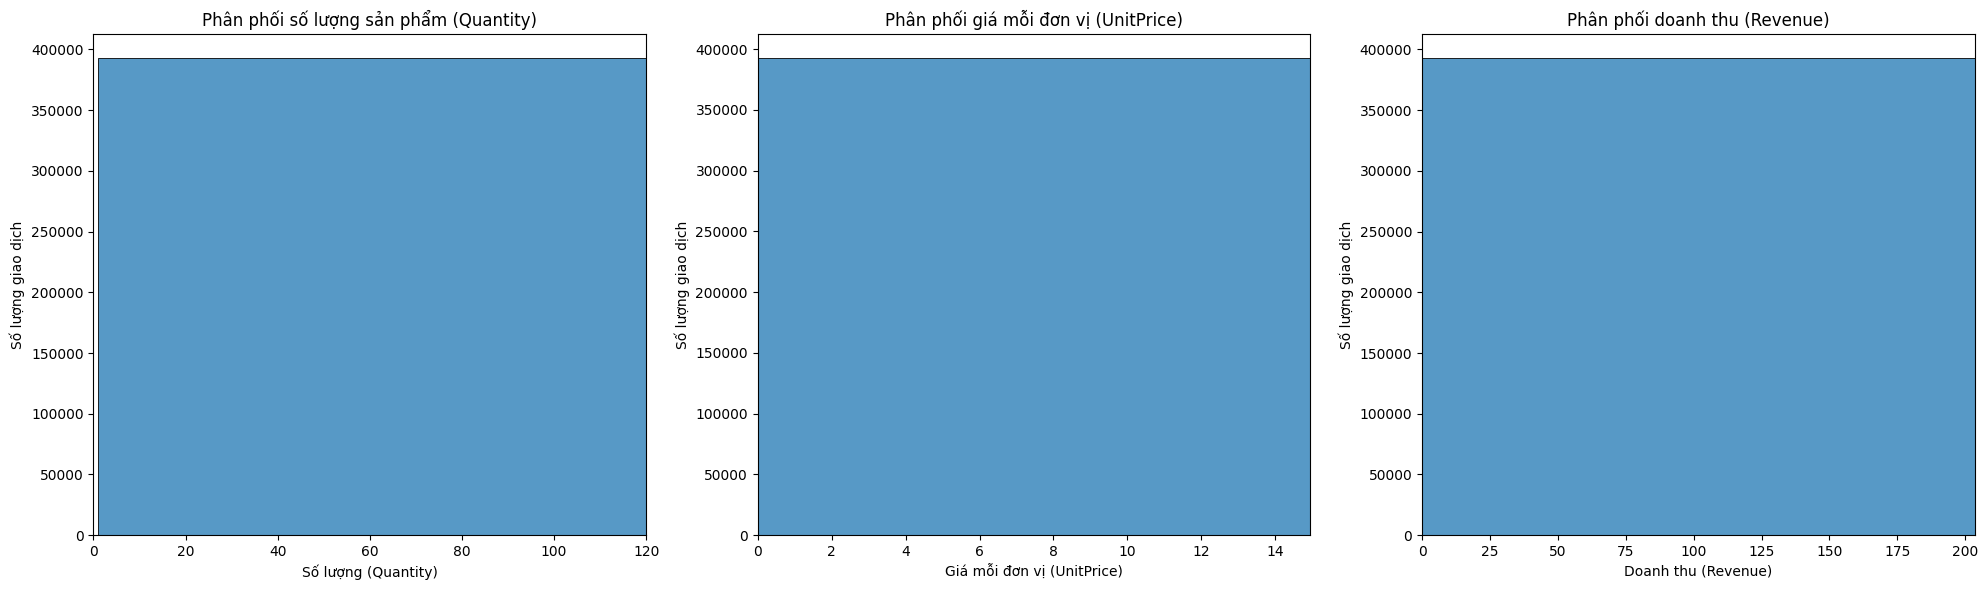

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Phân phối số lượng sản phẩm (Quantity)')
axes[0].set_xlabel('Số lượng (Quantity)')
axes[0].set_ylabel('Số lượng giao dịch')
axes[0].set_xlim(0, df['Quantity'].quantile(0.99)) # Giới hạn hiển thị để tránh các giá trị ngoại lai

sns.histplot(df['UnitPrice'], bins=50, ax=axes[1])
axes[1].set_title('Phân phối giá mỗi đơn vị (UnitPrice)')
axes[1].set_xlabel('Giá mỗi đơn vị (UnitPrice)')
axes[1].set_ylabel('Số lượng giao dịch')
axes[1].set_xlim(0, df['UnitPrice'].quantile(0.99)) # Giới hạn hiển thị để tránh các giá trị ngoại lai

sns.histplot(df['Revenue'], bins=50, ax=axes[2])
axes[2].set_title('Phân phối doanh thu (Revenue)')
axes[2].set_xlabel('Doanh thu (Revenue)')
axes[2].set_ylabel('Số lượng giao dịch')
axes[2].set_xlim(0, df['Revenue'].quantile(0.99)) # Giới hạn hiển thị để tránh các giá trị ngoại lai

plt.tight_layout()
plt.show()

### Phân tích doanh thu theo Quốc gia

Top 5 quốc gia đóng góp doanh thu nhiều nhất:


/tmp/ipykernel_1716/3660199441.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)


,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310


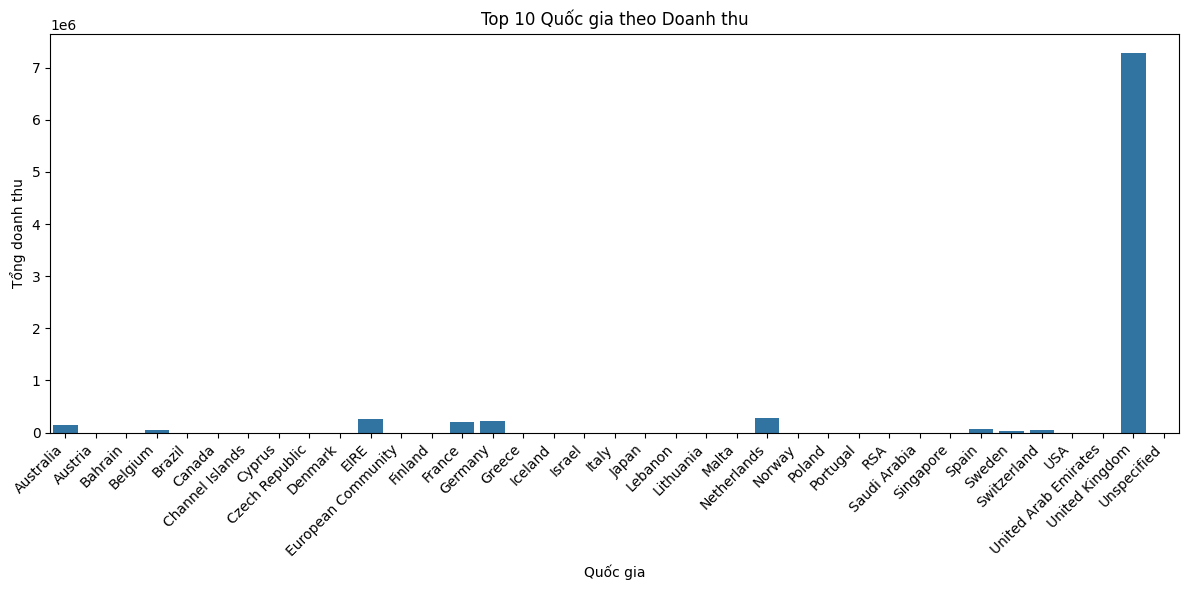

In [11]:
revenue_by_country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("Top 5 quốc gia đóng góp doanh thu nhiều nhất:")
display(revenue_by_country.head())

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_country.head(10).index, y=revenue_by_country.head(10).values)
plt.title('Top 10 Quốc gia theo Doanh thu')
plt.xlabel('Quốc gia')
plt.ylabel('Tổng doanh thu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
df_rfm = df.copy()
display(df_rfm.head())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# 5. Customer Analytics



##5.1 - Cohort Analysis

In [13]:
def get_month(x): return dt.datetime(x.year, x.month, 1)
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)
grouping = df.groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min')
display(grouping.min().head())

,InvoiceMonth
CustomerID,
12346,2011-01-01
12347,2010-12-01
12348,2010-12-01
12349,2011-11-01
12350,2011-02-01


In [14]:
df.tail()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011-12-01,2011-08-01
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-12-01,2011-08-01
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12-01,2011-08-01
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12-01,2011-08-01
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011-12-01,2011-08-01


In [15]:
def get_day(x):
    return dt.datetime(x.year, x.month, x.day)

df['InvoiceDay'] = df['InvoiceDate'].apply(get_day)


In [16]:
grouping = df.groupby('CustomerID')['InvoiceDay']
df['CohortDay'] = grouping.transform('min')
df.tail()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth,InvoiceDay,CohortDay
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011-12-01,2011-08-01,2011-12-09,2011-08-18
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-12-01,2011-08-01,2011-12-09,2011-08-18
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12-01,2011-08-01,2011-12-09,2011-08-18
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12-01,2011-08-01,2011-12-09,2011-08-18
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011-12-01,2011-08-01,2011-12-09,2011-08-18


In [17]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

InvoiceYear, InvoiceMonth, InvoiceDay = get_date_int(df, 'InvoiceDay')
CohortYear, CohortMonth, CohortDay = get_date_int(df, 'CohortMonth')

In [18]:
display(CohortMonth.head())

,CohortMonth
0,12
1,12
2,12
3,12
4,12


In [19]:
years_diff = InvoiceYear - CohortYear
months_diff = InvoiceMonth - CohortMonth

df['CohortIndex'] = years_diff * 12 + months_diff + 1

In [20]:
grouping = df.groupby(
    ['CohortMonth', 'CohortIndex']
)
cohort_data = (
    grouping['CustomerID']
    .nunique()
    .reset_index()
)
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)


In [21]:
display(cohort_counts)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
retention = cohort_counts.div(cohort_counts.iloc[:, 0], axis=0)
display(retention.round(2))



CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.37,0.32,0.38,0.36,0.40,0.36,0.35,0.35,0.40,0.37,0.50,0.27
2011-01-01,1.0,0.22,0.27,0.23,0.32,0.29,0.25,0.24,0.30,0.33,0.36,0.12,NaN
2011-02-01,1.0,0.19,0.19,0.28,0.27,0.25,0.25,0.28,0.25,0.31,0.07,NaN,NaN
2011-03-01,1.0,0.15,0.25,0.20,0.22,0.17,0.27,0.23,0.28,0.09,NaN,NaN,NaN
2011-04-01,1.0,0.21,0.20,0.21,0.20,0.23,0.22,0.26,0.07,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.19,0.17,0.17,0.21,0.23,0.26,0.10,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.17,0.16,0.26,0.23,0.33,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.18,0.21,0.22,0.27,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.21,0.25,0.24,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
type(retention.index)
retention.index = retention.index.strftime('%Y-%m')

<Axes: title={'center': 'Retention Rate'}, xlabel='CohortIndex', ylabel='CohortMonth'>

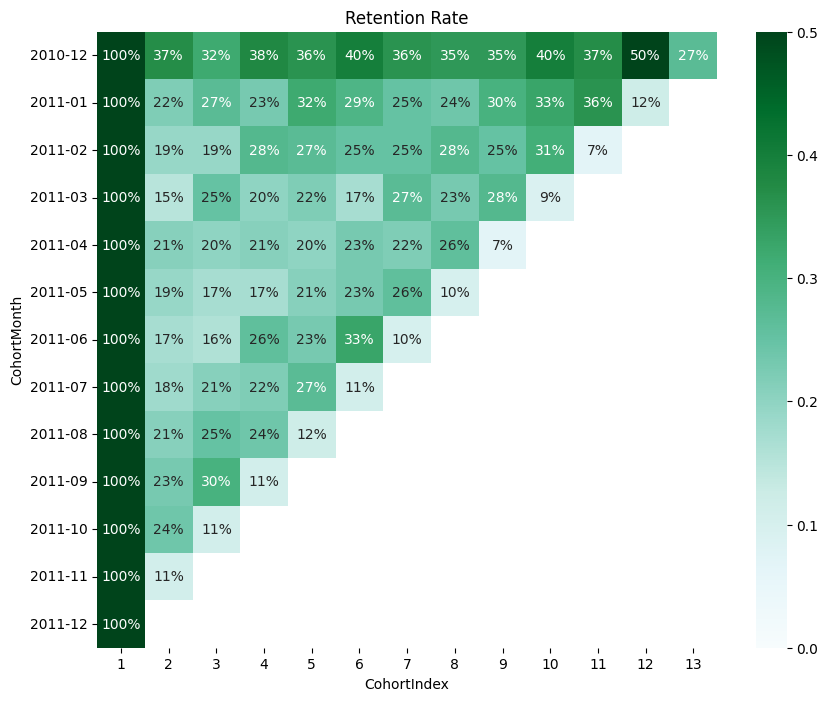

In [25]:
plt.figure(figsize= (10,8))
plt.title("Retention Rate")
sns.heatmap(data=retention.round(2), annot=True, fmt='.0%',vmin = 0.0, vmax = 0.5, cmap='BuGn')

In [26]:
grouping = df.groupby(
    ['CohortMonth', 'CohortIndex']
)

cohort_data = (
    grouping['Quantity']
    .sum()
    .reset_index()
)
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Quantity'
)
display(cohort_counts)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,311048.0,158440.0,136642.0,177170.0,131185.0,178267.0,178357.0,176898.0,206035.0,249535.0,255211.0,294807.0,110345.0
2011-01-01,190033.0,29517.0,38275.0,35000.0,46282.0,49460.0,41568.0,42636.0,43818.0,52980.0,59963.0,13586.0,NaN
2011-02-01,98868.0,19072.0,36333.0,29958.0,27953.0,24809.0,30413.0,36452.0,32239.0,36206.0,6039.0,NaN,NaN
2011-03-01,113065.0,16684.0,34581.0,24006.0,33496.0,27369.0,39589.0,48868.0,47723.0,9380.0,NaN,NaN,NaN
2011-04-01,72164.0,14564.0,12548.0,15384.0,16066.0,17444.0,18692.0,20615.0,3882.0,NaN,NaN,NaN,NaN
2011-05-01,69212.0,10476.0,12887.0,11699.0,16747.0,20399.0,20980.0,86915.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,60214.0,13328.0,7685.0,20645.0,18580.0,25350.0,5856.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,48990.0,6889.0,9721.0,10926.0,10936.0,3704.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,48581.0,9863.0,15401.0,17228.0,6344.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
growth = cohort_counts.div(cohort_counts.iloc[:, 0], axis=0)
display(growth.round(2))

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.51,0.44,0.57,0.42,0.57,0.57,0.57,0.66,0.80,0.82,0.95,0.35
2011-01-01,1.0,0.16,0.20,0.18,0.24,0.26,0.22,0.22,0.23,0.28,0.32,0.07,NaN
2011-02-01,1.0,0.19,0.37,0.30,0.28,0.25,0.31,0.37,0.33,0.37,0.06,NaN,NaN
2011-03-01,1.0,0.15,0.31,0.21,0.30,0.24,0.35,0.43,0.42,0.08,NaN,NaN,NaN
2011-04-01,1.0,0.20,0.17,0.21,0.22,0.24,0.26,0.29,0.05,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.15,0.19,0.17,0.24,0.29,0.30,1.26,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.22,0.13,0.34,0.31,0.42,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.14,0.20,0.22,0.22,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.20,0.32,0.35,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# RFM analytics


In [28]:
df_rfm['Total_Price'] = df_rfm['Quantity'] * df_rfm['UnitPrice']
display(df_rfm.head())
snapshot = df_rfm['InvoiceDate'].max() + pd.Timedelta(days=1)
display(snapshot)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Total_Price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,20.34


Timestamp('2011-12-10 12:50:00')

In [29]:
datamart = df_rfm.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total_Price': 'sum'
})
datamart.columns = ['Recency', 'Frequency', 'Monetary']
display(datamart.head())


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [30]:
r_labels = [4,3,2,1]
datamart['R'] = pd.qcut(datamart['Recency'], q=4, labels=r_labels)

f_labels = [1,2,3,4]
datamart['F'] = pd.qcut(datamart['Frequency'].rank(method='first'), q=4, labels=f_labels)

m_labels = [1,2,3,4]
datamart['M'] = pd.qcut(datamart['Monetary'], q=4, labels=m_labels)
display(datamart.head())



,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12346,326,1,77183.60,1,1,4
12347,2,7,4310.00,4,4,4
12348,75,4,1797.24,2,3,4
12349,19,1,1757.55,3,1,4
12350,310,1,334.40,1,1,2


In [31]:
datamart['RFM_Segment'] = datamart['R'].astype(str) + datamart['F'].astype(str) + datamart['M'].astype(str)
datamart['RFM_Score'] = datamart[['R', 'F', 'M']].sum(axis=1)
display(datamart.head())

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,4,114,6
12347,2,7,4310.00,4,4,4,444,12
12348,75,4,1797.24,2,3,4,234,9
12349,19,1,1757.55,3,1,4,314,8
12350,310,1,334.40,1,1,2,112,4


In [32]:
datamart.groupby('RFM_Score').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

Recency Frequency Monetary      
             mean      mean     mean count
RFM_Score                                 
3          267.83      1.00   161.19   300
4          206.94      1.09   257.30   506
5          134.40      1.31   369.68   485
6           94.61      1.62   660.27   504
7           78.74      2.15   737.24   431
8           61.69      2.83  1130.95   435
9           42.67      3.65  1364.96   410
10          34.56      5.09  2396.83   391
11          20.91      7.72  3787.35   387
12           7.42     15.53  9047.80   489

| **Segment** | **RFM Criteria** | **Business Objective** | **Behavior Description** | **Recommended Marketing Strategy** |
|:------------|:-----------------|:-----------------------|:-------------------------|:-----------------------------------|
| **Champions (VIP)** | R: 4–5, F: 4–5, M: 4–5 | Retain and maximize lifetime value | Purchased recently, shops frequently, and spends significantly. | Offer early access to new products, exclusive rewards, VIP appreciation programs, and premium customer services. |
| **Loyal Customers** | R: 3–5, F: 3–5, M: 3–5 | Increase customer loyalty | Makes regular purchases and responds well to promotional campaigns. | Provide loyalty programs, personalized offers, reward points, and cross-selling opportunities. |
| **New Customers** | R: 4–5, F: 1–2, M: 1–2 | Encourage repeat purchases | Recently made their first purchase or has just started shopping with the company. | Send welcome emails, onboarding guides, personalized recommendations, and vouchers for the second purchase. |
| **At Risk** | R: 1–2, F: 3–5, M: 3–5 | Win back valuable customers | Previously purchased frequently and spent a significant amount but has not returned for a long time. | Launch win-back campaigns, send "We Miss You" emails, and offer attractive discounts. |
| **About to Sleep** | R: 2–3, F: 1–2, M: 1–2 | Prevent customer churn | Purchases infrequently and shows declining engagement. | Recommend popular products, send reminder emails, and encourage re-engagement. |
| **Hibernating / Lost** | R: 1, F: 1, M: 1 | Minimize marketing costs | Displays consistently low engagement across all RFM dimensions and is likely inactive. | Send low-cost automated reactivation offers. If unsuccessful, reduce future marketing investment. |

In [33]:
def rfm_segment(df):
    R = df['R']
    F = df['F']
    M = df['M']

    # Champions (VIP)
    if R >= 4 and F >= 4 and M >= 4:
        return 'Champions'

    # Loyal Customers
    elif R >= 3 and F >= 3 and M >= 3:
        return 'Loyal Customers'

    # New Customers
    elif R >= 4 and F <= 2 and M <= 2:
        return 'New Customers'

    # At Risk
    elif R <= 2 and F >= 3 and M >= 3:
        return 'At Risk'

    # About to Sleep
    elif 2 <= R <= 3 and F <= 2 and M <= 2:
        return 'About to Sleep'

    # Hibernating / Lost
    elif R == 1 and F == 1 and M == 1:
        return 'Hibernating / Lost'

    # Other
    else:
        return 'Others'

datamart['RFM_Segmentation'] = datamart.apply(rfm_segment, axis=1)
display(datamart.head())

,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,RFM_Segmentation
CustomerID,,,,,,,,,
12346,326,1,77183.60,1,1,4,114,6,Others
12347,2,7,4310.00,4,4,4,444,12,Champions
12348,75,4,1797.24,2,3,4,234,9,At Risk
12349,19,1,1757.55,3,1,4,314,8,Others
12350,310,1,334.40,1,1,2,112,4,Others


### Visualization segment RFM

In [34]:
datamart.groupby('RFM_Segmentation').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)


Recency Frequency Monetary      
                      mean      mean     mean count
RFM_Segmentation                                   
About to Sleep       61.98      1.27   311.13   798
At Risk             106.22      4.68  2128.69   449
Champions             7.42     15.53  9047.80   489
Hibernating / Lost  267.83      1.00   161.19   300
Loyal Customers      22.84      5.76  2493.14   828
New Customers        10.36      1.46   314.03   179
Others              154.07      1.93   841.61  1295

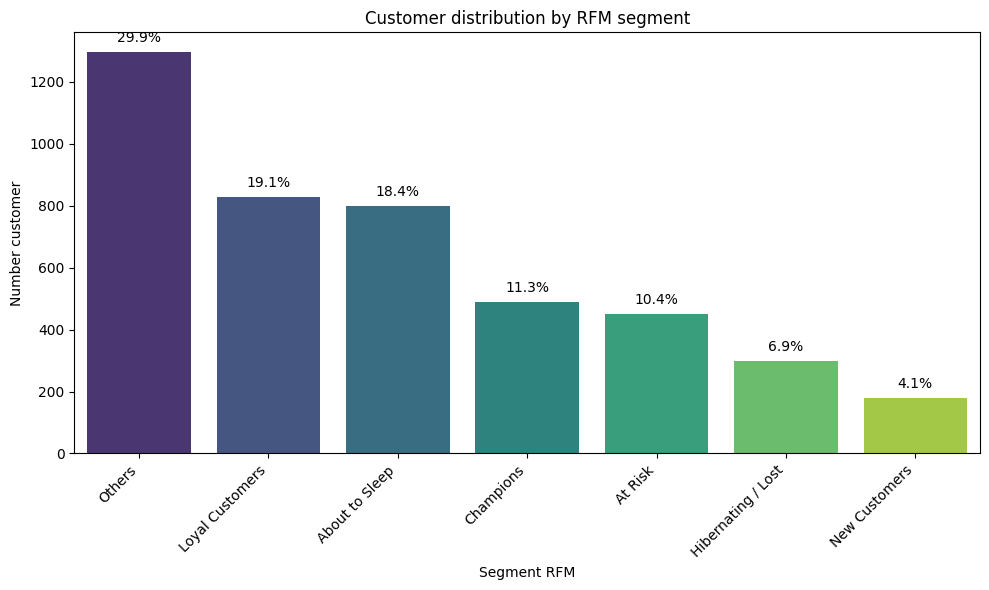

Customer proportion by RFM segment:


,proportion
RFM_Segmentation,
Others,29.85%
Loyal Customers,19.09%
About to Sleep,18.40%
Champions,11.27%
At Risk,10.35%
Hibernating / Lost,6.92%
New Customers,4.13%


In [35]:
segment_counts = datamart['RFM_Segmentation'].value_counts().sort_values(ascending=False)
segment_percentages = datamart['RFM_Segmentation'].value_counts(normalize=True).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax, palette='viridis', hue=segment_counts.index, legend=False)
ax.set_title('Customer distribution by RFM segment')
ax.set_xlabel('Segment RFM')
ax.set_ylabel('Number customer')
plt.xticks(rotation=45, ha='right')

for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(f'{segment_percentages.iloc[i]:.1%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

print("Customer proportion by RFM segment:")
display(segment_percentages.apply(lambda x: f'{x:.2%}'))

In [79]:
datamart.to_csv('rfm_segmentation.csv', index=True)